In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8
})

RANDOM_STATE = 42
CSV_PATH = "housing.csv"          # update path for a different dataset
TARGET_COL = "median_house_value" # target column name

In [3]:
df = pd.read_csv(r"C:\Users\yaksh\Downloads\HousingData.csv")

In [4]:
print("DataFrame shape:", df.shape)

DataFrame shape: (506, 14)


In [5]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.006,18.000,2.310,0.000,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980,24.000
1,0.027,0.000,7.070,0.000,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140,21.600
2,0.027,0.000,7.070,0.000,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030,34.700
3,0.032,0.000,2.180,0.000,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940,33.400
4,0.069,0.000,2.180,0.000,0.458,7.147,54.200,6.062,3,222,18.700,396.900,NaN,36.200


In [6]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: median_house_value
Numerical columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
Categorical columns: []


In [9]:
# missing values analysis
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64


In [10]:
# check presence of encoded missing values
for col in df.columns:
    print(df[col].value_counts().head(20))

CRIM
14.334    2
0.015     2
0.006     1
0.050     1
0.025     1
0.025     1
0.013     1
0.062     1
0.055     1
0.033     1
0.030     1
0.034     1
0.040     1
0.037     1
0.051     1
0.035     1
0.067     1
0.045     1
0.066     1
0.241     1
Name: count, dtype: int64
ZN
0.000     360
20.000     20
80.000     14
22.000     10
12.500     10
25.000     10
45.000      6
40.000      6
30.000      5
90.000      5
95.000      4
60.000      4
33.000      4
21.000      4
55.000      3
70.000      3
75.000      3
52.500      3
35.000      2
82.500      2
Name: count, dtype: int64
INDUS
18.100    127
19.580     28
8.140      22
6.200      18
21.890     14
3.970      12
9.900      12
10.590     11
8.560      11
10.010      9
5.860       9
2.460       8
5.190       8
7.380       8
6.910       8
9.690       8
7.870       7
3.440       6
5.130       6
12.830      6
Name: count, dtype: int64
CHAS
0.000    452
1.000     34
Name: count, dtype: int64
NOX
0.538    23
0.713    18
0.437    17
0.871    16

In [11]:
# duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicate rows:", num_duplicates)

# (optional) drop duplicates if present
# df = df.drop_duplicates()
# print("Shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


In [12]:
# descriptive stat
df[num_cols].describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000,486.000,486.000,486.000,506.000,506.000,486.000,506.000,506.000,506.000,506.000,506.000,486.000,506.000
mean,3.612,11.212,11.084,0.070,0.555,6.285,68.519,3.795,9.549,408.237,18.456,356.674,12.715,22.533
std,8.720,23.389,6.836,0.255,0.116,0.703,28.000,2.106,8.707,168.537,2.165,91.295,7.156,9.197
min,0.006,0.000,0.460,0.000,0.385,3.561,2.900,1.130,1.000,187.000,12.600,0.320,1.730,5.000
25%,0.082,0.000,5.190,0.000,0.449,5.885,45.175,2.100,4.000,279.000,17.400,375.377,7.125,17.025
50%,0.254,0.000,9.690,0.000,0.538,6.208,76.800,3.207,5.000,330.000,19.050,391.440,11.430,21.200
75%,3.560,12.500,18.100,0.000,0.624,6.623,93.975,5.188,24.000,666.000,20.200,396.225,16.955,25.000
max,88.976,100.000,27.740,1.000,0.871,8.780,100.000,12.127,24.000,711.000,22.000,396.900,37.970,50.000


In [13]:
# descriptive stat
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CRIM,486.000,3.612,8.720,0.006,0.082,0.254,3.560,88.976
ZN,486.000,11.212,23.389,0.000,0.000,0.000,12.500,100.000
INDUS,486.000,11.084,6.836,0.460,5.190,9.690,18.100,27.740
CHAS,486.000,0.070,0.255,0.000,0.000,0.000,0.000,1.000
NOX,506.000,0.555,0.116,0.385,0.449,0.538,0.624,0.871
RM,506.000,6.285,0.703,3.561,5.885,6.208,6.623,8.780
AGE,486.000,68.519,28.000,2.900,45.175,76.800,93.975,100.000
DIS,506.000,3.795,2.106,1.130,2.100,3.207,5.188,12.127
RAD,506.000,9.549,8.707,1.000,4.000,5.000,24.000,24.000
TAX,506.000,408.237,168.537,187.000,279.000,330.000,666.000,711.000


In [14]:
# countplot for categorical columns
for col in cat_cols:
    plt.figure(figsize=(10, 3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.show()

In [15]:
for col in cat_cols:
    print(df[col].value_counts())

In [17]:
print(df.columns)

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [18]:
TARGET_COL = "MEDV"

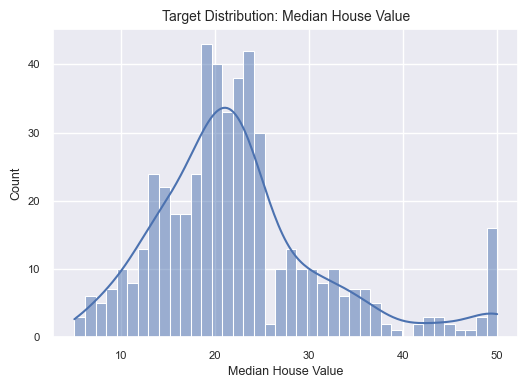

In [19]:
# target column distribution
plt.figure(figsize=(6,4))
sns.histplot(df[TARGET_COL], bins=40, kde=True)
plt.title("Target Distribution: Median House Value")
plt.xlabel("Median House Value")
plt.show()

In [20]:
df[TARGET_COL].value_counts()
# higher cap

MEDV
50.000    16
25.000     8
22.000     7
21.700     7
23.100     7
          ..
32.900     1
34.600     1
30.300     1
33.300     1
8.100      1
Name: count, Length: 229, dtype: int64

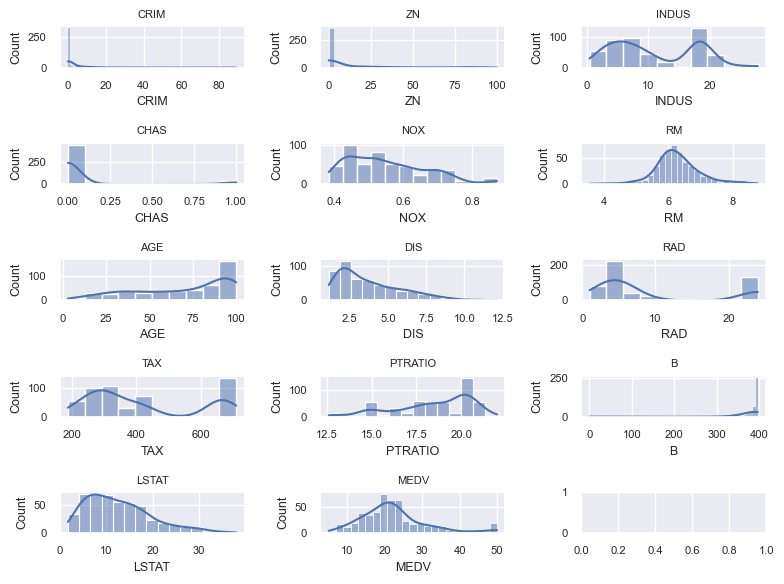

In [22]:
# histogram plot - distribution
fig, axes = plt.subplots(5, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col, fontsize=8)

plt.tight_layout()
plt.show()

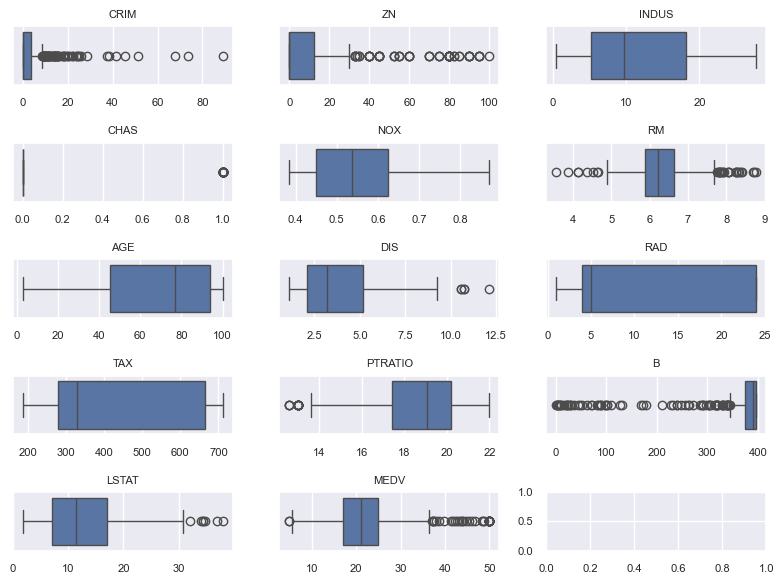

In [24]:
# outliers analysis - boxplot
fig, axes = plt.subplots(5, 3, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

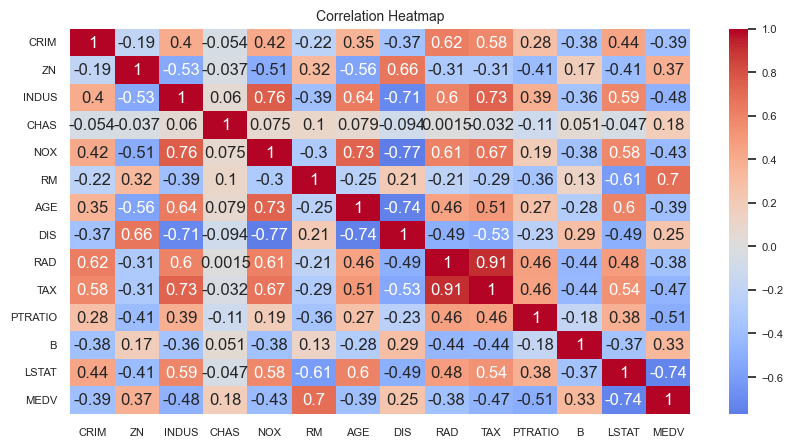

In [25]:
# identify presence of highly correlated columns & feature relationships
plt.figure(figsize=(10, 5))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

In [26]:
# Correlation with target
corr_with_target = df[num_cols].corr()[TARGET_COL].sort_values(ascending=False)
print("\nCorrelation with target:")
print(corr_with_target)


Correlation with target:
MEDV       1.000
RM         0.695
ZN         0.373
B          0.333
DIS        0.250
CHAS       0.181
RAD       -0.382
CRIM      -0.391
AGE       -0.395
NOX       -0.427
TAX       -0.469
INDUS     -0.482
PTRATIO   -0.508
LSTAT     -0.736
Name: MEDV, dtype: float64


In [27]:
# separate features and target
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [28]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.006,18.000,2.310,0.000,0.538,6.575,65.200,4.090,1,296,15.300,396.900,4.980
1,0.027,0.000,7.070,0.000,0.469,6.421,78.900,4.967,2,242,17.800,396.900,9.140
2,0.027,0.000,7.070,0.000,0.469,7.185,61.100,4.967,2,242,17.800,392.830,4.030
3,0.032,0.000,2.180,0.000,0.458,6.998,45.800,6.062,3,222,18.700,394.630,2.940
4,0.069,0.000,2.180,0.000,0.458,7.147,54.200,6.062,3,222,18.700,396.900,NaN


In [29]:
y.head()

0   24.000
1   21.600
2   34.700
3   33.400
4   36.200
Name: MEDV, dtype: float64

In [30]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

In [31]:
print("Train shape:", X_train.shape)

print("Test shape:", X_test.shape)

Train shape: (404, 13)
Test shape: (102, 13)


In [34]:
numerical_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

print("numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# numerical features - preprocessing steps
numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# categorical features - preprocessing steps
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# preprocessing pipeline
preprocess = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

numerical features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Categorical features: []


In [35]:
baseline_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", LinearRegression())
    ]
)

In [36]:
# preprocess the data and train the baseline model
baseline_pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [37]:
train_baseline_pred = baseline_pipe.predict(X_train)
test_baseline_pred = baseline_pipe.predict(X_test)

In [38]:
train_baseline_pred[:5]

array([10.64422972, 19.40058283, 22.33138139, 12.35572431, 18.40256763])

In [39]:
y_train[:5]

477   12.000
15    19.900
332   19.400
423   13.400
19    18.200
Name: MEDV, dtype: float64

In [40]:
train_baseline_rmse = root_mean_squared_error(y_train, train_baseline_pred)
train_baseline_mae = mean_absolute_error(y_train, train_baseline_pred)
train_baseline_r2 = r2_score(y_train, train_baseline_pred)

print("\n=== TRAIN BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {train_baseline_rmse:.3f}")
print(f"MAE : {train_baseline_mae:.3f}")
print(f"R2  : {train_baseline_r2:.3f}")


=== TRAIN BASELINE METRICS (LinearRegression) ===
RMSE: 4.728
MAE : 3.353
R2  : 0.743


In [41]:
test_baseline_rmse = root_mean_squared_error(y_test, test_baseline_pred)
test_baseline_mae = mean_absolute_error(y_test, test_baseline_pred)
test_baseline_r2 = r2_score(y_test, test_baseline_pred)

print("\n=== TEST BASELINE METRICS (LinearRegression) ===")
print(f"RMSE: {test_baseline_rmse:.3f}")
print(f"MAE : {test_baseline_mae:.3f}")
print(f"R2  : {test_baseline_r2:.3f}")


=== TEST BASELINE METRICS (LinearRegression) ===
RMSE: 4.998
MAE : 3.148
R2  : 0.659


In [42]:
# models to try
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_STATE),
    "Lasso": Lasso(random_state=RANDOM_STATE, max_iter=10000),
    "RandomForest": RandomForestRegressor(),
    "HistGB": HistGradientBoostingRegressor()
}

In [43]:
k = 5
cv = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)

In [44]:
scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

In [45]:
rows = []

for name, model in models.items():
    pipe = Pipeline(
        steps=[
            ("preprocess", preprocess),
            ("model", model)
        ]
    )
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({
        "model": name,
        "cv_rmse": -scores["test_rmse"].mean(),
        "cv_mae": -scores["test_mae"].mean(),
        "cv_r2": scores["test_r2"].mean()        
    })


# sort based on lowest rmse value
cv_results = pd.DataFrame(rows).sort_values("cv_rmse")
print("=== CV Model Comparison ===")
print(cv_results)

=== CV Model Comparison ===
              model  cv_rmse  cv_mae  cv_r2
4            HistGB    3.747   2.533  0.831
3      RandomForest    4.161   2.604  0.788
1             Ridge    4.994   3.475  0.704
0  LinearRegression    4.997   3.480  0.703
2             Lasso    5.520   3.802  0.637


In [46]:
cv_results


,model,cv_rmse,cv_mae,cv_r2
4,HistGB,3.747,2.533,0.831
3,RandomForest,4.161,2.604,0.788
1,Ridge,4.994,3.475,0.704
0,LinearRegression,4.997,3.480,0.703
2,Lasso,5.520,3.802,0.637


In [47]:
best_row = cv_results.sort_values("cv_rmse").iloc[0]

best_model_name = best_row["model"]
best_rmse = best_row["cv_rmse"]

print("Best model based on CV RMSE:")
print("Model :", best_model_name)
print("CV RMSE:", best_rmse)

Best model based on CV RMSE:
Model : HistGB
CV RMSE: 3.7466067700750925


In [48]:
hgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE))
    ]
)

In [49]:
# hyperparameters combination
param_grid = {
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__max_depth": [None, 3, 6],
    "model__max_leaf_nodes": [15, 31, 63],
    "model__min_samples_leaf": [20, 50, 100],
    "model__l2_regularization": [0.0, 0.1, 1.0]
}

In [50]:
grid = GridSearchCV(
    estimator=hgb_pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

In [52]:
# perform grid search
grid.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__l2_regularization': [0.0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [None, 3, ...], 'model__max_leaf_nodes': [15, 31, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [53]:
print("\n=== TUNED HistGB (CV) ===")
print("Best CV RMSE:", -grid.best_score_)
print("Best params:", grid.best_params_)


=== TUNED HistGB (CV) ===
Best CV RMSE: 3.7466067700750925
Best params: {'model__l2_regularization': 0.0, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 15, 'model__min_samples_leaf': 20}


In [54]:
hgb_best = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_depth=None,
            max_leaf_nodes=63,
            min_samples_leaf=20
        ))
    ]
)# train best model on entire training data (can also be done with refit=True in grid search)
hgb_best.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True



=== FINAL MODEL (Tuned HGB) Train Performance ===
RMSE: 1.596
MAE : 0.950
R2  : 0.971

=== FINAL MODEL (Tuned HGB) Test Performance ===
RMSE: 3.201
MAE : 2.128
R2  : 0.860


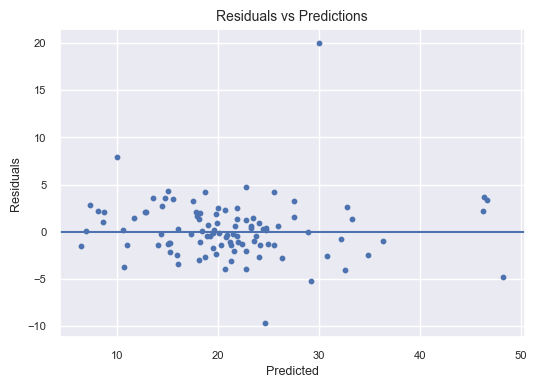

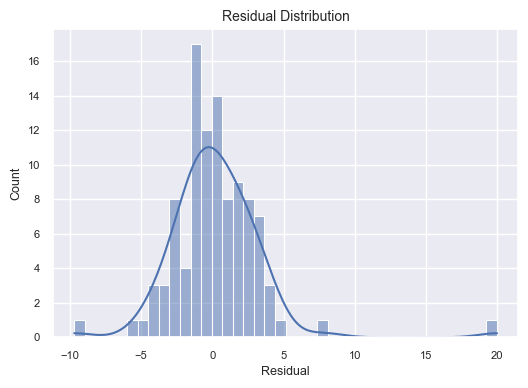

In [55]:
train_final_pred = hgb_best.predict(X_train)

train_final_rmse = root_mean_squared_error(y_train, train_final_pred)
train_final_mae = mean_absolute_error(y_train, train_final_pred)
train_final_r2 = r2_score(y_train, train_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Train Performance ===")
print(f"RMSE: {train_final_rmse:.3f}")
print(f"MAE : {train_final_mae:.3f}")
print(f"R2  : {train_final_r2:.3f}")
test_final_pred = hgb_best.predict(X_test)

test_final_rmse = root_mean_squared_error(y_test, test_final_pred)
test_final_mae = mean_absolute_error(y_test, test_final_pred)
test_final_r2 = r2_score(y_test, test_final_pred)

print("\n=== FINAL MODEL (Tuned HGB) Test Performance ===")
print(f"RMSE: {test_final_rmse:.3f}")
print(f"MAE : {test_final_mae:.3f}")
print(f"R2  : {test_final_r2:.3f}")
# residual plot
residuals = y_test - test_final_pred

plt.figure(figsize=(6, 4))
plt.scatter(test_final_pred, residuals, s=10)
plt.axhline(0)
plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(6, 4))
sns.histplot(residuals, bins=40, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.show()

In [56]:
def predict_house_price(
    model,
    longitude: float,
    latitude: float,
    housing_median_age: float,
    total_rooms: float,
    total_bedrooms: float,
    population: float,
    households: float,
    median_income: float,
    ocean_proximity: str
) -> float:
    """
    Predict median_house_value for one new house.
    total_bedrooms can be np.nan (pipeline will impute).
    """
    new_row = pd.DataFrame([{
        "longitude": longitude,
        "latitude": latitude,
        "housing_median_age": housing_median_age,
        "total_rooms": total_rooms,
        "total_bedrooms": total_bedrooms,
        "population": population,
        "households": households,
        "median_income": median_income,
        "ocean_proximity": ocean_proximity
    }])

    return float(model.predict(new_row)[0])

In [58]:
import numpy as np
import pandas as pd

# Create example input as DataFrame
example_data = pd.DataFrame([{
    "CRIM": 0.00632,
    "ZN": 18.0,
    "INDUS": 2.31,
    "CHAS": 0,
    "NOX": 0.538,
    "RM": 6.575,
    "AGE": 65.2,
    "DIS": 4.0900,
    "RAD": 1,
    "TAX": 296,
    "PTRATIO": 15.3,
    "B": 396.90,
    "LSTAT": 4.98
}])

# Predict
example_pred = hgb_best.predict(example_data)

print("Example prediction:", round(example_pred[0], 2))

Example prediction: 29.25
